# Safeguard playground

A self-contained sandbox for the **statistical safeguard** — the rule that picks the exploitation
depth $N$ from a pilot estimate instead of from a grid-tuned constant.

Nothing here imports from `qmetrology/`; every piece is re-implemented in the notebook so you can
edit it freely without touching the library. Only `numpy`, `scipy` and `matplotlib` are needed.

**What is in here**

1. The circuit simulator and the estimator
2. The three safeguards: constant $C$, statistical (normal), statistical (truncated normal)
3. The two algorithms — reverse engineering and binary search — each with all three safeguards
4. Head-to-head convergence comparison
5. **The optimisation landscape**: the objective over all candidate $N$, drawn many times so the
   pattern is visible — for both algorithms and both posteriors
6. The implied effective $C$
7. A playground cell at the end

**The rule.** Given a pilot $\hat\phi_0$ measured at depth $N_0$ with $m'$ shots, so that
$\sigma = 1/(2N_0\sqrt{m'})$, and a remaining budget $B$:

$$N^{*}=\arg\max_{N}\;\underbrace{\mathbb P\!\left(\phi<\tfrac{\pi}{2N}\mid\hat\phi_0\right)}_{\text{no overshoot}}\;\cdot\;\underbrace{\left[2\Phi\!\left(2\varepsilon\sqrt{NB}\right)-1\right]}_{\text{converges}}$$

The first factor falls with $N$, the second rises like $\sqrt N$; the maximiser balances them.

## 1. Simulator and estimator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr          # standard normal CDF, vectorised

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False,
})

# one fixed colour per quantity, used everywhere below
COL = {"valid": "#4C78A8",      # P(no overshoot)
       "conv":  "#F58518",      # P(converge)
       "prod":  "#333333",      # the objective we maximise
       "pick":  "#D6202B",      # the argmax
       "true":  "#3E9651",      # the true N_opt
       "const": "#8C6BB1"}      # the constant-C choice


def simulate(rng, phi, N, m):
    """One run of the entangled circuit: hits ~ Binomial(m, cos^2(N phi)), inverted to phi_hat.

    phi_hat lies in [0, pi/(2N)] by construction, so it ALIASES once N*phi > pi/2.
    """
    N = max(int(N), 1)
    if m <= 0:
        return np.nan
    hits = rng.binomial(m, np.cos(N * phi) ** 2)
    return np.arccos(np.sqrt(hits / m)) / N


def pilot_sd(N, m):
    """sd of a pilot taken at depth N with m shots: sqrt(1/(4 N^2 m)) — independent of phi."""
    return 1.0 / (2.0 * N * np.sqrt(m))


def n_min(phi_max):  return max(int(np.pi // (2 * phi_max)), 1)
def n_max(phi_min):  return max(int(np.pi // (2 * phi_min)), 1)
def n_opt(phi):      return max(int(np.pi // (2 * phi)), 1)

## 2. The three safeguards

`p_valid` is the only thing that differs between the two statistical variants:

* **normal** — $\Phi\!\left(\frac{\pi/(2N)-\hat\phi_0}{\sigma}\right)$
* **truncated** — the same, conditioned on $\phi\in[\phi_{\min},\phi_{\max}]$, which is the *exact*
  posterior under the uniform prior the experiment actually draws from

In [2]:
def p_valid(N, phi_hat, sigma, support=None):
    """P(phi < pi/(2N) | pilot). support=(phi_min, phi_max) -> exact truncated normal."""
    t = np.pi / (2.0 * np.asarray(N, float))
    if support is None:
        return ndtr((t - phi_hat) / sigma)
    lo, hi = support
    Fa, Fb = ndtr((lo - phi_hat) / sigma), ndtr((hi - phi_hat) / sigma)
    den = Fb - Fa
    if not np.isfinite(den) or den < 1e-12:        # posterior collapsed onto a boundary
        return (t > min(max(phi_hat, lo), hi)).astype(float)
    return np.clip((ndtr((t - phi_hat) / sigma) - Fa) / den, 0.0, 1.0)


def p_conv(N, budget, eps):
    """P(|phi_hat - phi| < eps) at depth N with m = B/N shots.  N^2 m = N B, so this is phi-free."""
    return 2.0 * ndtr(2.0 * eps * np.sqrt(np.asarray(N, float) * budget)) - 1.0


def objective(N, phi_hat, sigma, budget, eps, support=None):
    return p_valid(N, phi_hat, sigma, support) * p_conv(N, budget, eps)


def depth_statistical(phi_hat, sigma, budget, eps, N_lo, N_hi, support=None):
    """N* = argmax of the objective. Exhaustive — N is an integer and no QC calls are involved."""
    if not np.isfinite(phi_hat) or sigma <= 0 or budget <= 0 or N_hi < N_lo:
        return max(N_lo, 1)
    Ns = np.arange(max(N_lo, 1), N_hi + 1)
    return int(Ns[int(np.argmax(objective(Ns, phi_hat, sigma, budget, eps, support)))])


def depth_constant(phi_hat, C, N_lo, N_hi):
    """The published rule: N = floor(pi/(2 phi_hat) * C) with C grid-tuned."""
    if not np.isfinite(phi_hat) or phi_hat <= 0:
        return max(N_lo, 1)
    return int(np.clip(int(np.pi // (2 * phi_hat) * C), max(N_lo, 1), N_hi))

## 3. The two algorithms

Each takes `mode` $\in$ `{"const", "normal", "trunc"}`. With `diag=True` they also return everything
needed to draw the landscape: the pilot, its $\sigma$, the admissible depth range, and the choice.

In [3]:
def reverse_engineering(rng, phi, phi_min, phi_max, m_pilot, budget, eps,
                        mode="trunc", C=0.9, diag=False):
    """Algorithm 6. Pilot at N_min (where the estimator cannot alias), then commit the rest."""
    N0, Nhi = n_min(phi_max), n_max(phi_min)
    if m_pilot * N0 > budget:
        return (np.inf, budget, None) if diag else (np.inf, budget)

    phi_hat, used, tries = 0.0, 0, 0
    while phi_hat == 0 and tries < 200:       # hits == m gives phi_hat == 0 and carries no info
        phi_hat = simulate(rng, phi, N0, m_pilot)
        used += m_pilot * N0
        tries += 1
    if phi_hat == 0:                          # pathological pilot; give up rather than spin
        return (phi_hat, used, None) if diag else (phi_hat, used)
    rem = budget - used
    if rem <= 0:
        return (phi_hat, used, None) if diag else (phi_hat, used)

    sigma = pilot_sd(N0, m_pilot)
    sup = (phi_min, phi_max) if mode == "trunc" else None
    if mode == "const":
        N = depth_constant(phi_hat, C, N0, Nhi)
    else:
        N = depth_statistical(phi_hat, sigma, rem, eps, N0, Nhi, sup)

    m = int(rem / N)
    out = simulate(rng, phi, N, m)
    info = dict(phi=phi, phi_hat0=phi_hat, sigma=sigma, budget=rem, eps=eps,
                N_lo=N0, N_hi=Nhi, N_pick=N, support=sup, mode=mode,
                naive=max(int(np.pi // (2 * phi_hat)), 1))
    return (out, used + N * m, info) if diag else (out, used + N * m)


def binary_search(rng, phi, phi_min, phi_max, m_pilot, budget, eps,
                  mode="trunc", s=1, conf=0.8, diag=False):
    """Algorithm 5. Bisect on N using the Eq.(3.4) overshoot test, then commit the rest.

    The pilot handed to the safeguard is the DEEPEST probe not flagged as an overshoot — the most
    precise estimate taken where the estimator is still valid.
    """
    N0, Nhi = n_min(phi_max), n_max(phi_min)
    if m_pilot * N0 > budget:
        return (np.inf, budget, None) if diag else (np.inf, budget)

    N = N0
    phi_hat = simulate(rng, phi, N, m_pilot)
    used = m_pilot * N
    thr = phi_hat - 1.2816 * pilot_sd(N, m_pilot)        # ~10% lower tail
    phi_acc, N_acc = phi_hat, N
    lb, ub = N0, Nhi
    N += (ub - N) // 2

    while True:
        phi_hat = simulate(rng, phi, N, m_pilot)
        used += m_pilot * N
        prev = N
        if phi_hat < thr:                                # looks like an overshoot -> go shallower
            N -= (N - lb) // 2
            ub = prev
        else:
            phi_acc, N_acc = phi_hat, prev
            N += (ub - N) // 2
            lb = prev
            thr = phi_hat - 1.2816 * pilot_sd(N, m_pilot)
        if prev == N or N < N0 or N > Nhi or used >= budget:
            break

    rem = budget - used
    if rem <= 0:
        return (phi_hat, used, None) if diag else (phi_hat, used)

    sigma = pilot_sd(N_acc, m_pilot)
    sup = (phi_min, phi_max) if mode == "trunc" else None
    # The statistical rule is NOT capped at the bisected N: the bisection halts when its step size
    # reaches zero and so undershoots, and capping there measurably costs convergence. The constant-s
    # rule keeps the published semantics (reduce the bisected N by s).
    if mode == "const":
        N_use = max(max(int(N), 1) - s, 1)
    else:
        N_use = depth_statistical(phi_acc, sigma, rem, eps, N0, Nhi, sup)

    m = int(rem / N_use)
    out = simulate(rng, phi, N_use, m)
    info = dict(phi=phi, phi_hat0=phi_acc, sigma=sigma, budget=rem, eps=eps,
                N_lo=N0, N_hi=Nhi, N_pick=N_use, support=sup, mode=mode,
                naive=max(int(np.pi // (2 * phi_acc)), 1))
    return (out, used + N_use * m, info) if diag else (out, used + N_use * m)

## 4. Head-to-head

Convergence = fraction of trials with $|\hat\phi-\phi|<\varepsilon$, with $\phi$ drawn from the
uniform prior each trial. Change `SETTING` and re-run.

In [4]:
SETTING = dict(phi_min=0.01, phi_max=0.1, eps=1e-3, budget=10_000, m_pilot=76)

# Binary search probes several depths before committing, so at budget 10,000 the exploration alone
# can exhaust it and the safeguard is never reached. Its panels use a budget where it actually runs.
SETTING_B = dict(phi_min=0.01, phi_max=0.1, eps=1e-3, budget=200_000, m_pilot=76)
R_TRIALS = 3000


def convergence(algo, mode, setting=SETTING, R=R_TRIALS, seed=2024, **kw):
    rng = np.random.default_rng(seed)
    s, ok = setting, 0
    for _ in range(R):
        phi = rng.uniform(s["phi_min"], s["phi_max"])
        est, _ = algo(rng, phi, s["phi_min"], s["phi_max"], s["m_pilot"],
                      s["budget"], s["eps"], mode=mode, **kw)
        if np.isfinite(est) and abs(est - phi) < s["eps"]:
            ok += 1
    return 100 * ok / R


rows = []
for name, algo, ckw in [("Reverse engineering", reverse_engineering, dict(C=0.85)),
                        ("Binary search", binary_search, dict(s=2))]:
    r = {"algorithm": name}
    st = SETTING if algo is reverse_engineering else SETTING_B
    r["constant C / s"] = convergence(algo, "const", st, **ckw)
    r["statistical (normal)"] = convergence(algo, "normal", st)
    r["statistical (truncated)"] = convergence(algo, "trunc", st)
    rows.append(r)

hdr = f"{'algorithm':<22}" + "".join(f"{k:>26}" for k in list(rows[0])[1:])
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['algorithm']:<22}" + "".join(f"{r[k]:>25.2f}%" for k in list(r)[1:]))
print(f"\n(R = {R_TRIALS} trials, SE ~{100*np.sqrt(0.25/R_TRIALS):.2f} pp;  "
      f"reverse engineering at B={SETTING['budget']:,}, binary search at B={SETTING_B['budget']:,})")

algorithm                         constant C / s      statistical (normal)   statistical (truncated)
----------------------------------------------------------------------------------------------------
Reverse engineering                       62.53%                    65.87%                    65.70%
Binary search                             86.50%                    98.23%                    98.23%

(R = 3000 trials, SE ~0.91 pp;  reverse engineering at B=10,000, binary search at B=200,000)


## 5. The optimisation landscape

The heart of the rule. For one trial, the objective is evaluated at **every** admissible $N$ and the
largest is taken. Below: the two factors and their product, with the choice marked.

* <span style="color:#4C78A8">**blue**</span> — $\mathbb P(\text{no overshoot})$, falls with $N$
* <span style="color:#F58518">**orange**</span> — $\mathbb P(\text{converge})$, rises like $\sqrt N$
* <span style="color:#333333">**black**</span> — the product, i.e. what is maximised
* <span style="color:#D6202B">**red line**</span> — the chosen $N^{*}$
* <span style="color:#3E9651">**green dashed**</span> — the true $N_{\text{opt}}=\lfloor\pi/2\phi\rfloor$ (unknowable in practice)
* <span style="color:#8C6BB1">**purple dotted**</span> — what the constant-$C$ rule would have picked

In [5]:
def plot_landscape(ax, info, C_ref=0.85, show_legend=False):
    """Draw the objective and its two factors over every admissible N for one trial."""
    Ns = np.arange(max(info["N_lo"], 1), info["N_hi"] + 1)
    if len(Ns) < 2:
        ax.text(0.5, 0.5, "range too small", ha="center", transform=ax.transAxes); return
    pv = p_valid(Ns, info["phi_hat0"], info["sigma"], info["support"])
    pc = p_conv(Ns, info["budget"], info["eps"])
    pr = pv * pc

    ax.plot(Ns, pv, color=COL["valid"], lw=1.3, label=r"$P(\mathrm{no\ overshoot})$")
    ax.plot(Ns, pc, color=COL["conv"], lw=1.3, label=r"$P(\mathrm{converge})$")
    ax.plot(Ns, pr, color=COL["prod"], lw=2.0, label="product (maximised)")
    ax.axvline(info["N_pick"], color=COL["pick"], lw=1.6, label=r"chosen $N^*$")
    ax.axvline(n_opt(info["phi"]), color=COL["true"], lw=1.4, ls="--", label=r"true $N_{opt}$")
    ax.axvline(min(int(info["naive"] * C_ref), info["N_hi"]), color=COL["const"], lw=1.3, ls=":",
               label=f"constant C={C_ref}")
    ax.set_ylim(-0.03, 1.05)
    ax.set_title(rf"$\phi$={info['phi']:.4f}  $\hat\phi_0$={info['phi_hat0']:.4f}  "
                 rf"$N^*$={info['N_pick']}  ($N_{{opt}}$={n_opt(info['phi'])})", fontsize=8)
    if show_legend:
        ax.legend(fontsize=7, loc="upper right")


def landscape_grid(algo, mode, setting=SETTING, n=12, seed=7, C_ref=0.85, **kw):
    """Many trials side by side — this is where the pattern shows up."""
    rng = np.random.default_rng(seed)
    infos = []
    for _ in range(60 * n):                   # bounded: exploration can eat the whole budget
        if len(infos) >= n:
            break
        phi = rng.uniform(setting["phi_min"], setting["phi_max"])
        *_, info = algo(rng, phi, setting["phi_min"], setting["phi_max"], setting["m_pilot"],
                        setting["budget"], setting["eps"], mode=mode, diag=True, **kw)
        if info is not None:
            infos.append(info)
    if not infos:
        raise RuntimeError(
            f"{algo.__name__}: the exploration phase consumed the whole budget in every trial, so "
            "the safeguard was never reached. Increase setting['budget'] or lower m_pilot.")
    infos.sort(key=lambda d: d["phi"])
    n = len(infos)
    ncol = 4; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.5 * nrow), squeeze=False)
    for i, ax in enumerate(axes.flat):
        if i < len(infos):
            plot_landscape(ax, infos[i], C_ref, show_legend=(i == 0))
            if i // ncol == nrow - 1: ax.set_xlabel("candidate depth $N$")
            if i % ncol == 0: ax.set_ylabel("probability")
        else:
            ax.axis("off")
    post = "truncated normal" if mode == "trunc" else "normal"
    fig.suptitle(f"{algo.__name__.replace('_',' ')} — objective over all N   ({post} posterior)",
                 fontsize=11)
    fig.tight_layout(); return fig


def landscape_overlay(algo, mode, setting=SETTING, n=60, seed=11, **kw):
    """Every trial's product curve on one axis, x rescaled by the true N_opt so they line up."""
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    phis, curves = [], []
    for _ in range(60 * n):                   # bounded, same reason as landscape_grid
        if len(curves) >= n:
            break
        phi = rng.uniform(setting["phi_min"], setting["phi_max"])
        *_, info = algo(rng, phi, setting["phi_min"], setting["phi_max"], setting["m_pilot"],
                        setting["budget"], setting["eps"], mode=mode, diag=True, **kw)
        if info is None: continue
        Ns = np.arange(max(info["N_lo"], 1), info["N_hi"] + 1)
        if len(Ns) < 3: continue
        pr = p_valid(Ns, info["phi_hat0"], info["sigma"], info["support"]) * \
             p_conv(Ns, info["budget"], info["eps"])
        phis.append(phi); curves.append((Ns / n_opt(phi), pr, info["N_pick"] / n_opt(phi)))
    if not curves:
        raise RuntimeError(f"{algo.__name__}: exploration consumed the whole budget in every trial; "
                           "increase setting['budget'].")
    lo, hi = min(phis), max(phis)
    cmap = plt.get_cmap("viridis")
    for phi, (x, y, xpick) in zip(phis, curves):
        c = cmap((phi - lo) / (hi - lo + 1e-12))
        ax.plot(x, y, color=c, lw=1.0, alpha=0.75)
        ax.plot([xpick], [y[np.argmin(np.abs(x - xpick))]], "o", color=c, ms=4)
    ax.axvline(1.0, color=COL["true"], ls="--", lw=1.4, label=r"$N=N_{opt}$ (aliasing edge)")
    ax.set(xlabel=r"depth relative to the true optimum,  $N/N_{opt}$",
           ylabel="objective (product)", xlim=(0, 1.6))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(lo, hi))
    fig.colorbar(sm, ax=ax, label=r"true $\phi$")
    ax.legend(fontsize=8, loc="upper left")
    post = "truncated normal" if mode == "trunc" else "normal"
    ax.set_title(f"{algo.__name__.replace('_',' ')} — {n} trials overlaid ({post} posterior)\n"
                 "dots mark the chosen depth", fontsize=10)
    fig.tight_layout(); return fig

### 5a. Reverse engineering — normal posterior

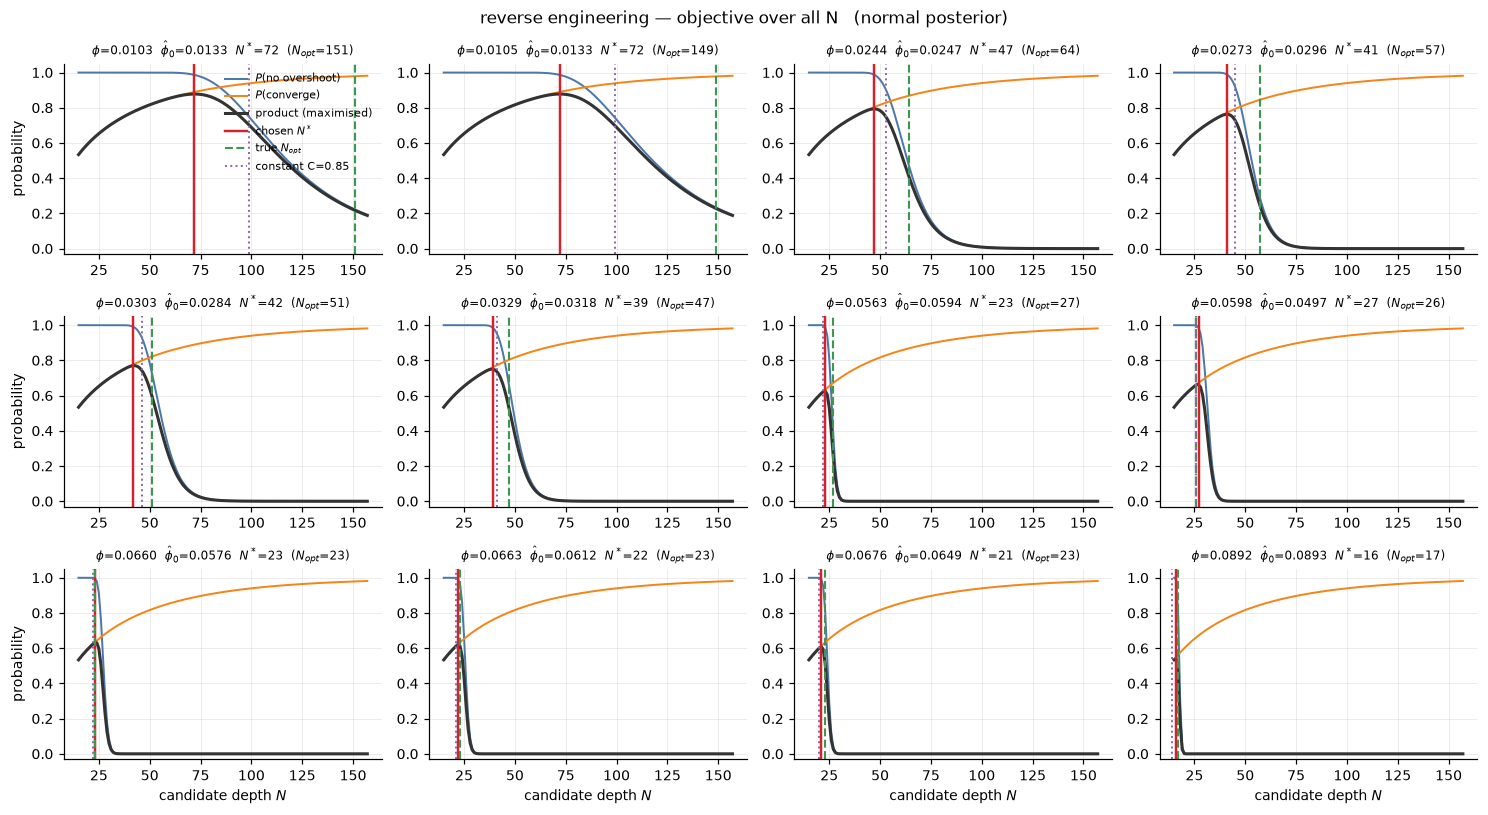

In [6]:
fig = landscape_grid(reverse_engineering, "normal"); plt.show()

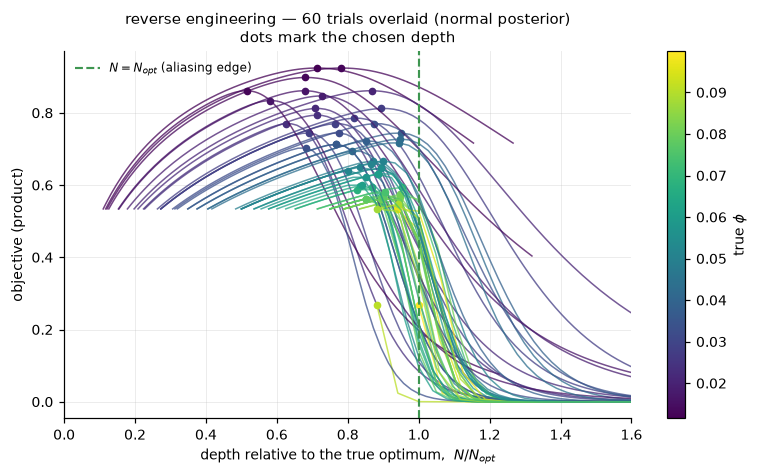

In [7]:
fig = landscape_overlay(reverse_engineering, "normal"); plt.show()

### 5b. Reverse engineering — truncated normal posterior

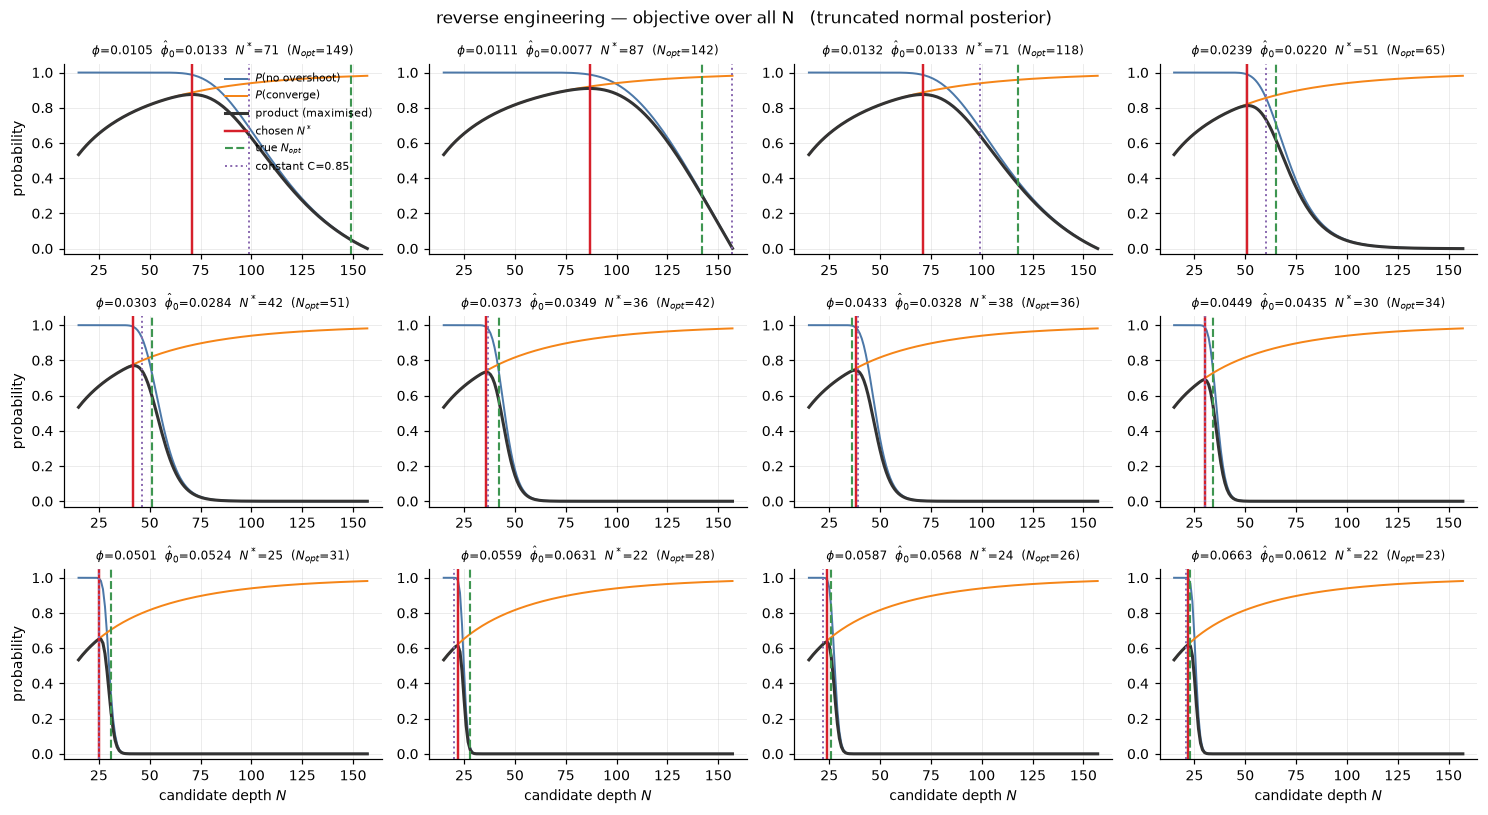

In [8]:
fig = landscape_grid(reverse_engineering, "trunc"); plt.show()

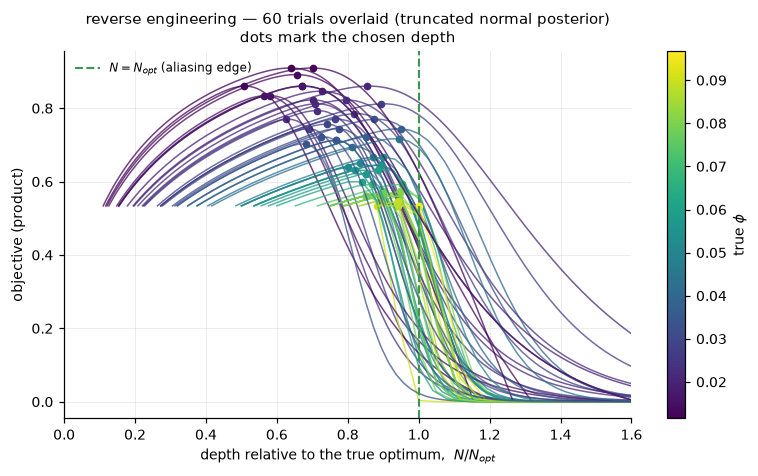

In [9]:
fig = landscape_overlay(reverse_engineering, "trunc"); plt.show()

### 5c. Binary search — normal posterior

The pilot here is far more precise than reverse engineering's: it was taken at a *deep* circuit, so
$\sigma = 1/(2N_{\text{acc}}\sqrt{m'})$ is small and the overshoot factor is close to a step.

The search deliberately runs over the **whole** prior range rather than stopping at the depth the
bisection settled on — the bisection halts when its step size hits zero and undershoots, so capping
there discards depths the posterior can justify (worth 1-2 pp; see
`results/SAFEGUARD_DERIVATION.md` §7). Binary search is best understood as buying a precise pilot,
not as selecting the depth itself.

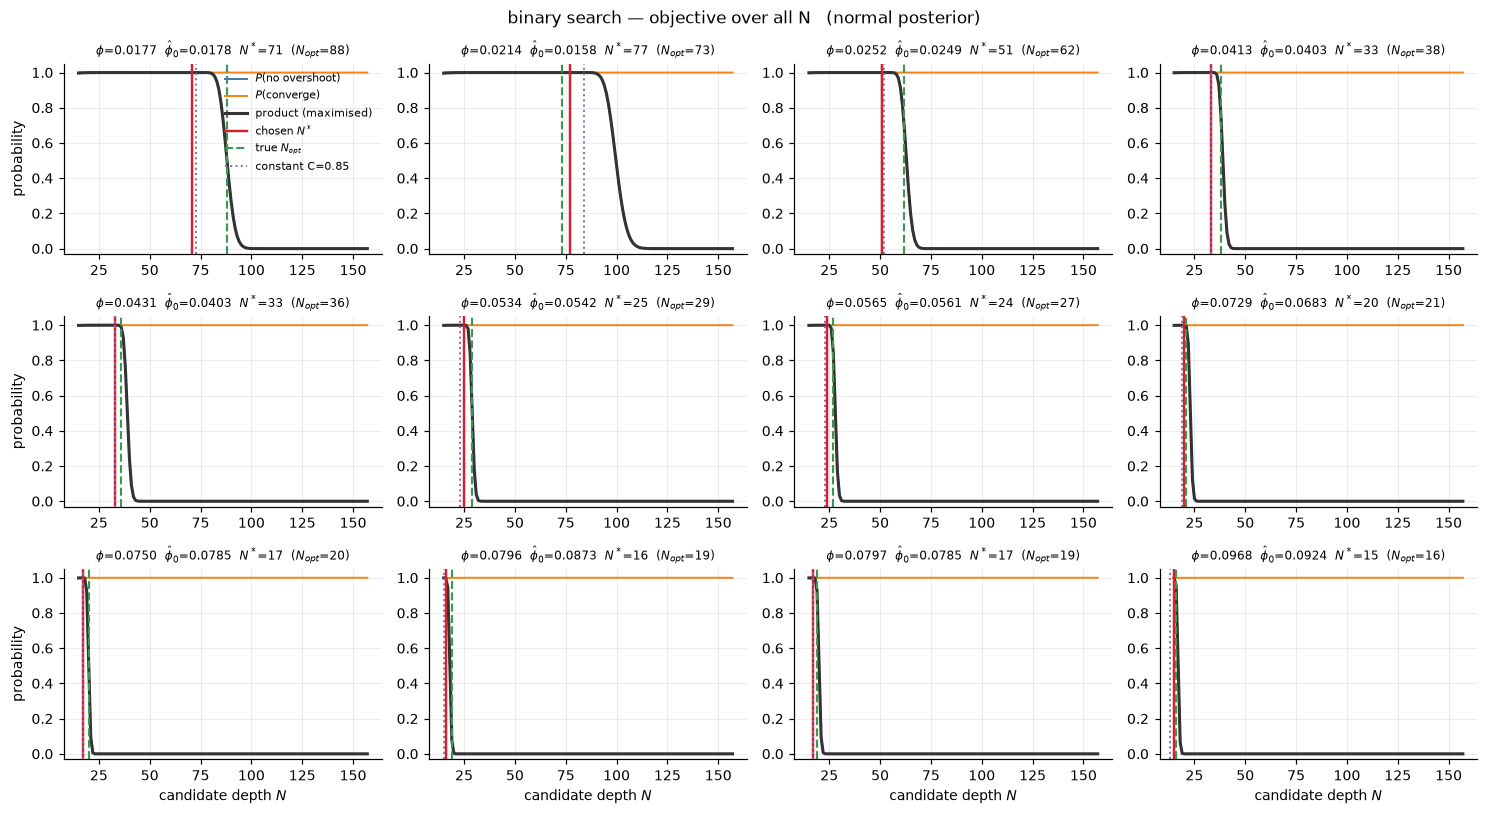

In [10]:
fig = landscape_grid(binary_search, "normal", SETTING_B, seed=3); plt.show()

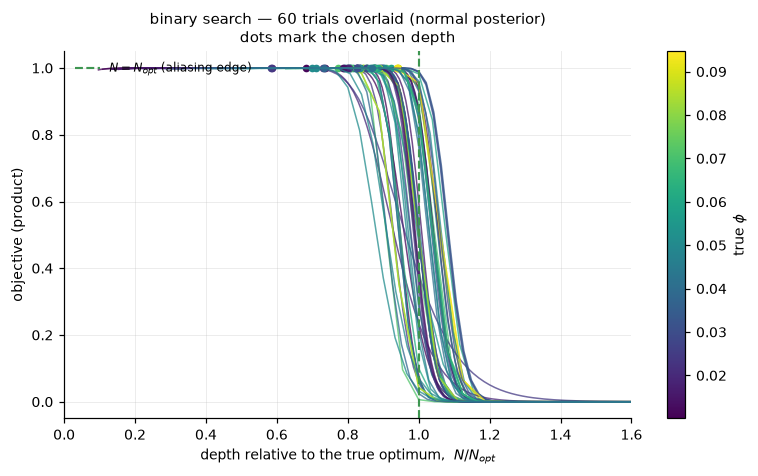

In [11]:
fig = landscape_overlay(binary_search, "normal", SETTING_B, seed=5); plt.show()

### 5d. Binary search — truncated normal posterior

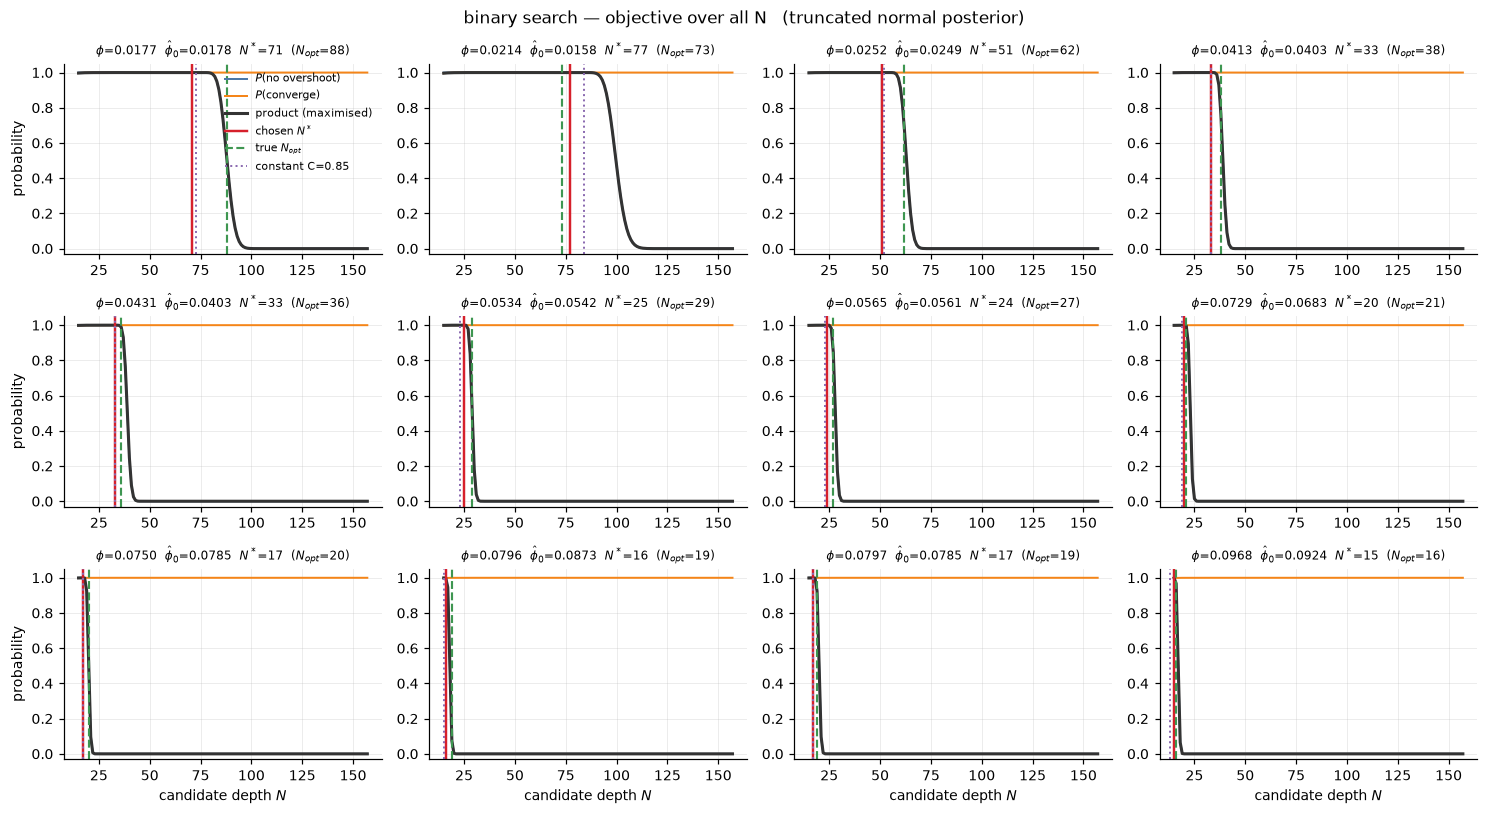

In [12]:
fig = landscape_grid(binary_search, "trunc", SETTING_B, seed=3); plt.show()

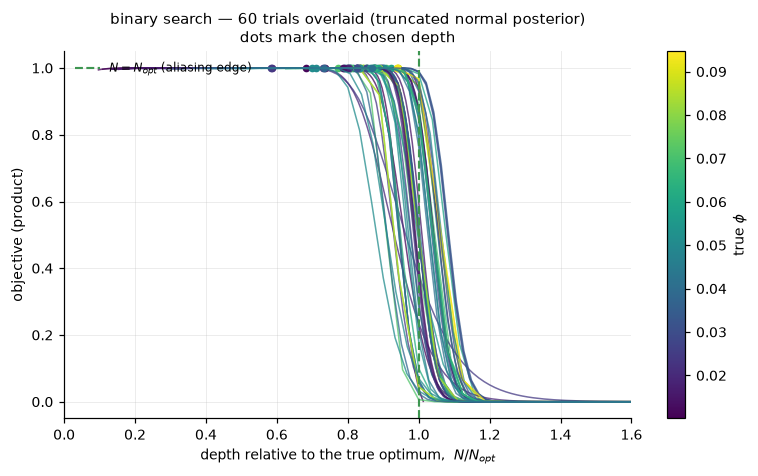

In [13]:
fig = landscape_overlay(binary_search, "trunc", SETTING_B, seed=5); plt.show()

## 6. The implied effective $C$

The statistical rule is equivalent to a multiplicative safeguard
$C_{\text{eff}} = N^{*}/\lfloor\pi/2\hat\phi_0\rfloor$ — but one that adapts to both $\phi$ and the
budget, which no single tuned constant can.

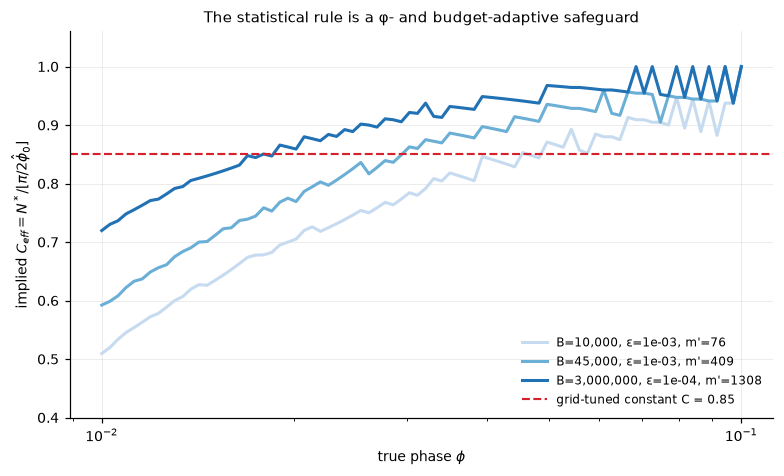

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
phis = np.geomspace(SETTING["phi_min"], SETTING["phi_max"], 80)
shades = ["#C6DBEF", "#6BAED6", "#2171B5"]
for (B, m_p, eps), c in zip([(1e4, 76, 1e-3), (4.5e4, 409, 1e-3), (3e6, 1308, 1e-4)], shades):
    N0, Nhi = n_min(SETTING["phi_max"]), n_max(SETTING["phi_min"])
    sd = pilot_sd(N0, m_p)
    ce = [depth_statistical(p, sd, B - m_p * N0, eps, N0, Nhi,
                            (SETTING["phi_min"], SETTING["phi_max"])) / max(int(np.pi // (2 * p)), 1)
          for p in phis]
    ax.plot(phis, ce, color=c, lw=2, label=f"B={B:,.0f}, ε={eps:.0e}, m'={m_p}")
ax.axhline(0.85, color=COL["pick"], ls="--", lw=1.4, label="grid-tuned constant C = 0.85")
ax.set(xscale="log", xlabel=r"true phase $\phi$", ylim=(0.4, 1.06),
       ylabel=r"implied $C_{eff} = N^*/\lfloor \pi/2\hat\phi_0\rfloor$")
ax.set_title("The statistical rule is a φ- and budget-adaptive safeguard", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

## 7. Playground

Everything above is driven by `SETTING`. Some things worth trying:

* set `phi_max = np.pi/2` — the broad prior, where $N_{\min}=1$ and the pilot is at its coarsest;
  this is where the constant-$C$ rule fails hardest
* shrink `budget` — watch $C_{\text{eff}}$ tighten as the precision factor stops saturating
* set `m_pilot = 20` — a deliberately bad pilot; the truncated and normal posteriors then visibly
  disagree near $\phi_{\min}$
* set `phi_min = 0.09, phi_max = 0.1` — a narrow prior, where truncation distorts the posterior most
  but the admissible $N$ range collapses, so the choice barely moves

reverse engineering    constant  70.80%   normal  75.37%   truncated  75.37%
binary search          constant  58.67%   normal  61.77%   truncated  61.77%


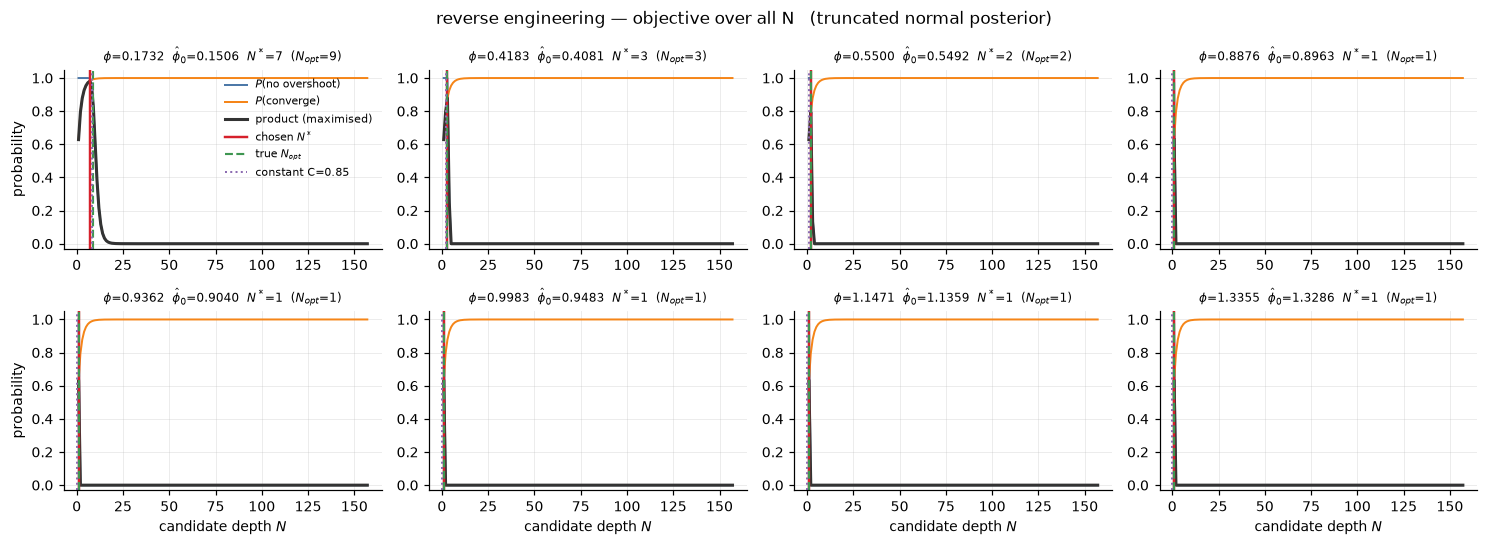

In [15]:
PLAY = dict(phi_min=0.01, phi_max=np.pi / 2, eps=1e-3, budget=200_000, m_pilot=400)

for algo, ckw in [(reverse_engineering, dict(C=0.85)), (binary_search, dict(s=2))]:
    name = algo.__name__.replace("_", " ")
    a = convergence(algo, "const", PLAY, **ckw)
    b = convergence(algo, "normal", PLAY)
    c = convergence(algo, "trunc", PLAY)
    print(f"{name:<22} constant {a:6.2f}%   normal {b:6.2f}%   truncated {c:6.2f}%")

fig = landscape_grid(reverse_engineering, "trunc", PLAY, n=8, seed=2); plt.show()